In [17]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
sns.set_theme()

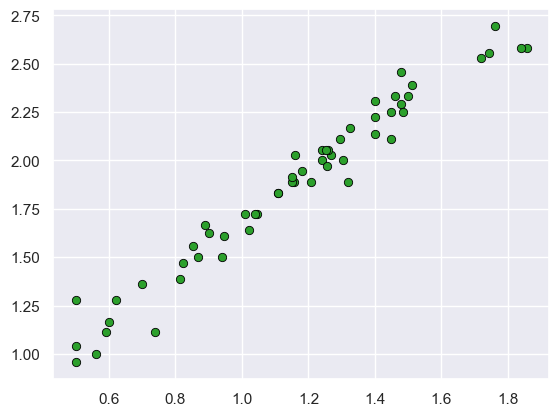

In [19]:
df = pd.read_csv('D:\machine_learning\lab_1\data\chirps.csv')

x = df['chirps_per_min'] / 100
y_gt = df['temp_C'] / 10

plt.scatter(x, y_gt, c='tab:green', edgecolors='black', linewidths=0.6, label='Dataset')


# Model

In [20]:
def model(_x, _w):
    return _w[0]*_x + _w[1]

# Test it
print(f'f(3.4, [0.4, -0.35]) = {model(3.4, [0.4, -0.35])}')
print(f'f([3.4, 1.0], [0.4, -0.35]) = {model(np.array([3.4, 1.0]), [0.4, -0.35])}')


f(3.4, [0.4, -0.35]) = 1.0100000000000002
f([3.4, 1.0], [0.4, -0.35]) = [1.01 0.05]



# Forward pass

In [21]:
def loss_fn(_y_pred, _y_gt):
    return np.mean(np.square(_y_pred - _y_gt))

# Test it
print(f'loss(3, 3) = {loss_fn(3, 3)}')
print(f'loss(3, 2) = {loss_fn(3, 2)}')
print(f'loss(0, 2) = {loss_fn(0, 2)}')
print(f'loss([0, 1], [3, 1]) = {loss_fn(np.array([0, 1]), np.array([3, 1]))}')


loss(3, 3) = 0.0
loss(3, 2) = 1.0
loss(0, 2) = 4.0
loss([0, 1], [3, 1]) = 4.5


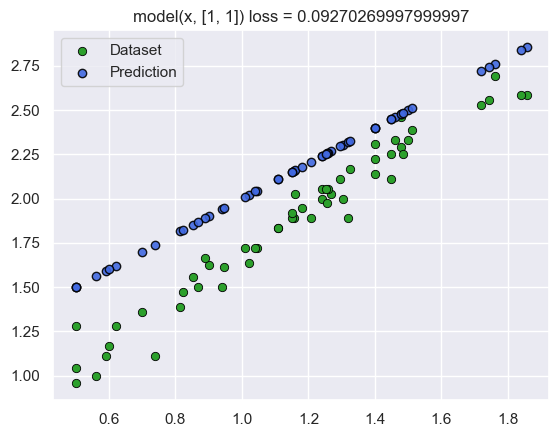

In [27]:
# TODO: Create model initial weights
w = [1, 1]

y_pred = model(x, w)
loss = loss_fn(y_pred, y_gt)

plt.scatter(x, y_gt, c='tab:green', edgecolors='black', linewidths=0.6, label='Dataset')
plt.scatter(x, y_pred, color='royalblue', label='Prediction', edgecolors='black', alpha=0.9)
plt.title(f'model(x, {w}) loss = {loss}')
plt.legend()

# Training

In [28]:
# Step 1
# Given initial model weights
w = [1,0]

# Step 2
# TODO: Make forward pass
y_pred = model(x,w)

# Step 3
# TODO: Calculate loss
L = loss_fn(y_pred, y_gt)
print(f'Loss={L}')

# Step 3 (backward pass)
# TODO: Calculate gradients
grad1 = np.mean(2 * (y_gt - y_pred) * x) * -1
grad2 = np.mean(2 * (y_gt - y_pred) * 1) * -1

# TODO: Update weights
lf = 10**(-3)
w[0] = w[0] - grad1 * lf
w[1] = w[1] - grad2 * lf

y_pred = model(x, w)
# Step 4
# TODO: Recalculate loss
L_after = loss_fn(y_pred, y_gt)
print(f'Loss after backward pas={L_after}')



Loss=0.5342528817981819
Loss after backward pas=0.5292289162246486


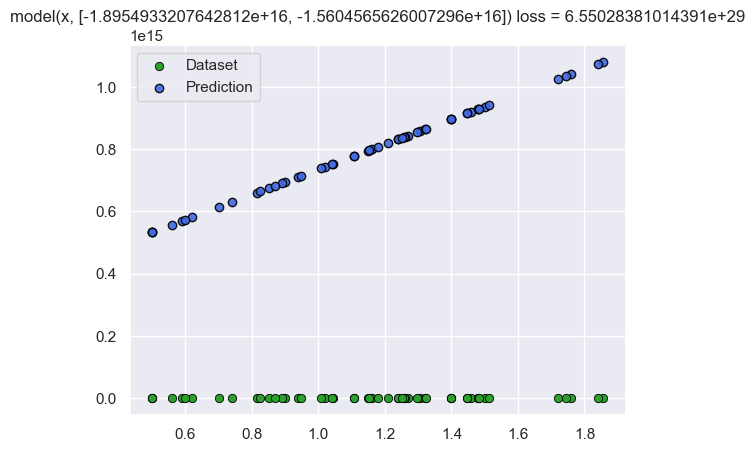

In [ ]:
# TODO: Having the code snippet above run it in the loop to perform multiple epochs (iterations)

# Step 1
# Given initial model weights
w = [1,0]

for epochs in range(10):  # One iteration you used all the data once called an "epoch"
    y_pred = model(x,w)
    L = loss_fn(y_pred, y_gt)

    grad1 = np.mean(2 * (y_gt - y_pred) * x) * -1
    grad2 = np.mean(2 * (y_gt - y_pred) * 1) * -1

    lf = 10**(-3)
    w[0] = w[0] - grad1 * lf
    w[1] = w[1] - grad2 * lf

plt.scatter(x, y_gt, c='tab:green', edgecolors='black', linewidths=0.6, label='Dataset')
plt.scatter(x, y_pred, color='royalblue', label='Prediction', edgecolors='black', alpha=0.9)
plt.title(f'model(x, {w}) loss = {L}')
plt.legend()



In [ ]:
# TODO: Plot loss change over training